In [14]:
%matplotlib inline

%load_ext autoreload
%autoreload 2

from hubble_fit import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [15]:
df_agn = load_quasar_data("data/aug10_stonebwb_recalc_N20w2000s1000t6c4.h5", populate_sdss=False)

print(list(df_agn.keys()))


Reading quasars from HDF5:   0%|          | 0/189 [00:00<?, ?it/s]

Reading quasars from HDF5: 100%|██████████| 189/189 [00:01<00:00, 173.33it/s]

Number of quasars loaded: 189
Length of colin_df: 189
Number with apparent_mag_2500 > 0: 189
Length of merged DataFrame: 189
object_id not in merged: []
Number of quasars with 0 < z <= 1.0: 33
Number of quasars with z > 3: 9
Highest redshift quasar: 4.15
Columns with NaNs: ['chi_sq_g', 'chi_sq_all']
Number of quasars with 0 < z <= 1.0: 31
Number of dropped quasars with 0 < z <= 1.0: 2
Number of quasars with z > 3: 8
Final number of quasars: 186
['object_id', 'EXTINCTION', 'FHOST_5100', 'LOGL1350', 'LOGL1350_ERR', 'LOGL1700', 'LOGL1700_ERR', 'LOGL2500', 'LOGL2500_ERR', 'LOGL3000', 'LOGL3000_ERR', 'LOGL5100', 'LOGL5100_ERR', 'LOGLBOL', 'M_i', 'alpha_host', 'alpha_host_err', 'bwb_alpha', 'bwb_alpha_err', 'bwb_beta', 'bwb_beta_err', 'clean_bands', 'dec', 'ebv', 'eta_A1', 'eta_A1_err', 'eta_A1_mean', 'eta_A1_mean_err', 'eta_A2', 'eta_A2_err', 'eta_A2_mean', 'eta_A2_mean_err', 'eta_break', 'eta_break_err', 'eta_tau1', 'eta_tau1_err', 'eta_tau1_mean', 'eta_tau1_mean_err', 'eta_tau2', 'eta_tau

In [16]:
df_agn

,object_id,EXTINCTION,FHOST_5100,LOGL1350,LOGL1350_ERR,LOGL1700,LOGL1700_ERR,LOGL2500,LOGL2500_ERR,LOGL3000,...,sigma_eta_tau2,sigma_eta_tau2_err,sn_median_all,z,chi_sq_g,chi_sq_all,alpha_nu,alpha_nu_err,f_host_4200,apparent_mag_2500
0,1386553,0.145489,0.0,0.000000,-1.000000,45.723232,0.007319,45.618650,0.003656,45.570288,...,0.229484,0.098257,6.846294,1.431358,NaN,NaN,-0.5,0.1,-1.0,21.431567
1,1386655,0.149691,0.0,45.987854,0.000000,45.978610,0.003002,45.853233,0.014771,45.843914,...,0.193559,0.083412,6.923154,1.886809,NaN,NaN,-0.5,0.1,-1.0,21.727196
2,1386671,0.122158,0.0,45.593462,0.000000,45.530562,0.002458,45.405746,0.002635,45.352760,...,0.123347,0.080672,8.390502,1.689144,NaN,NaN,-0.5,0.1,-1.0,22.491450
3,1386720,0.150925,0.0,0.000000,-1.000000,0.000000,-1.000000,44.998006,0.007158,44.992640,...,0.154597,0.045067,5.084220,0.923101,NaN,NaN,-0.5,0.1,-1.0,21.621281
4,1386822,0.134770,0.0,45.949927,0.002796,45.956153,0.002289,46.070247,0.004657,0.000000,...,0.118114,0.125081,9.786992,2.464000,NaN,NaN,-0.5,0.1,-1.0,22.044209
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
181,1391454,0.054722,0.0,0.000000,-1.000000,0.000000,-1.000000,45.202332,0.002175,45.233662,...,0.192412,0.105010,22.399614,0.725000,164.579358,525.191885,-0.5,0.1,-1.0,20.163407
182,1391583,0.058153,0.0,45.646733,0.007195,45.610035,0.003076,45.546058,0.004123,45.533106,...,0.123347,0.080672,7.921389,1.786000,379.273277,970.463726,-0.5,0.1,-1.0,22.256181
183,1391675,0.055048,0.0,45.618676,0.004976,45.618892,0.002923,45.564871,0.003501,45.516858,...,0.141100,0.102101,8.803846,1.835000,63.403570,227.418574,-0.5,0.1,-1.0,22.303621
184,1391766,0.060308,0.0,45.406413,0.007805,45.521285,0.001966,45.637222,0.002770,45.636472,...,0.240514,0.082861,8.065370,1.834000,117.099560,136.271079,-0.5,0.1,-1.0,22.120346


In [94]:
bands = ['u', 'g', 'r', 'i', 'z']

from collections import OrderedDict

def sdss_broad_lines_by_band(z):
    """
    Return a dict mapping each SDSS band to the name of a broad line
    whose observed wavelength falls inside that band's (approximate) range
    at redshift z. If none, returns "none" for that band.

    Notes:
    - Filter edges are approximated as simple top-hats (Å).
    - Lines are checked in priority order; if multiple lines land in a band,
      the first match is returned.
    """

    # --- approximate SDSS bandpass ranges (Å); simple top-hat model ---
    bands = {
        "u": (3000.0, 4000.0),
        "g": (4000.0, 5500.0),
        "r": (5500.0, 7000.0),
        "i": (7000.0, 8500.0),
        "z": (8500.0, 10000.0),
    }

    # --- common broad lines (rest Å), in priority order ---
    lines = OrderedDict([
        ("Lyα 1216", 1215.67),
        #("N V 1240", 1240.81),
        #("Si IV+O IV] 1400", 1397.0),
        ("C IV 1549", 1549.0),
        #("He II 1640", 1640.0),
        ("C III] 1909", 1908.73),
        ("Mg II 2798", 2798.0),
        #("Hγ 4340", 4340.47),
        ("Hβ 4861", 4861.33),
        ("Hα 6563", 6562.80),
    ])

    out = {}
    for band, (lo, hi) in bands.items():
        hit = "none"
        for name, lam0 in lines.items():
            lam_obs = lam0 * (1.0 + z)
            if lo <= lam_obs <= hi:
                hit = name
                break
        out[band] = hit
    return out

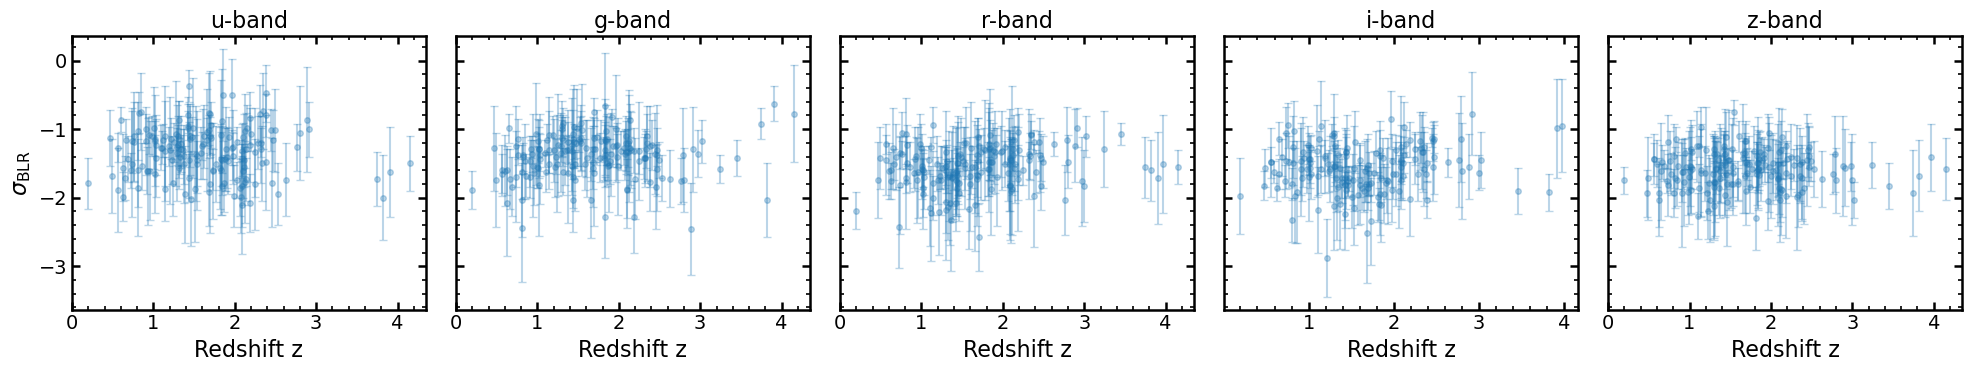

In [109]:
import matplotlib.pyplot as plt
import numpy as np

bands = ['u', 'g', 'r', 'i', 'z']

fig, axes = plt.subplots(1, len(bands), figsize=(4 * len(bands), 4), sharey=True)

for i, b in enumerate(bands):
    z = df_agn['z']
    sigma_blr = df_agn[f'log_sigma_band_{b}'] + df_agn[f'log_amp_delta_blr_{b}']
    sigma_blr_err = np.sqrt(df_agn[f'log_sigma_band_{b}_err']**2 + df_agn[f'log_amp_delta_blr_{b}_err']**2)
    mask = sigma_blr_err < 0.8
    axes[i].errorbar(z[mask], sigma_blr[mask], yerr=sigma_blr_err[mask], linestyle='none', marker='o', alpha=0.3)
    axes[i].set_title(f'{b}-band')
    axes[i].set_xlabel('Redshift z')
    if i == 0:
        axes[i].set_ylabel(r'$\sigma_\mathrm{BLR}$')

plt.tight_layout()

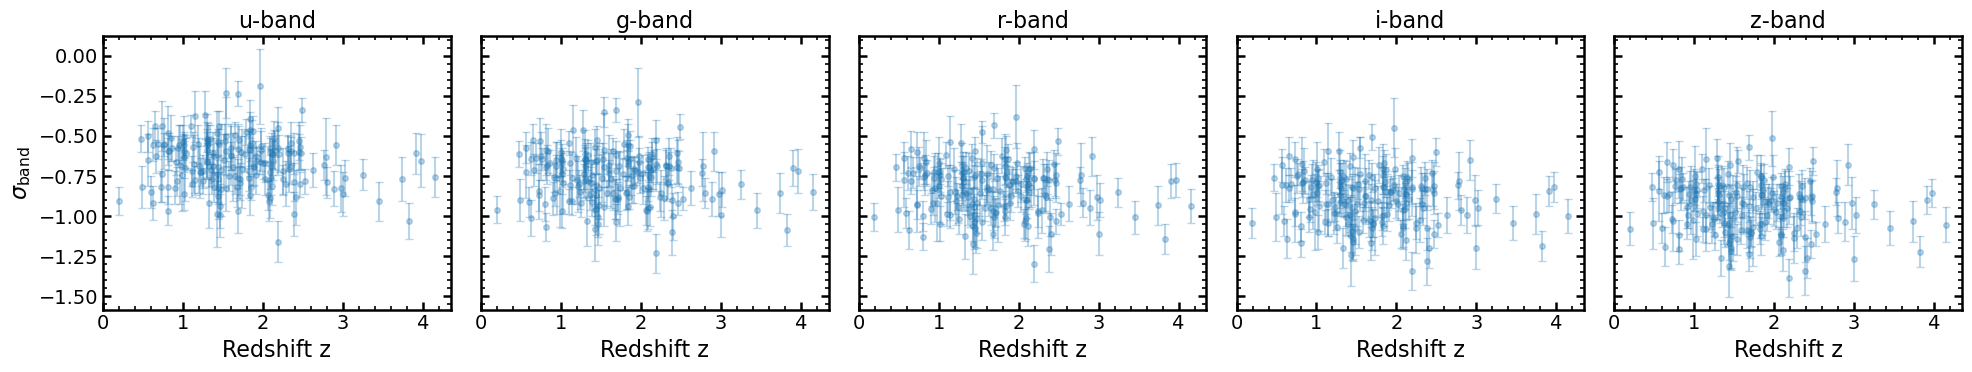

In [110]:
import matplotlib.pyplot as plt
import numpy as np

bands = ['u', 'g', 'r', 'i', 'z']

fig, axes = plt.subplots(1, len(bands), figsize=(4 * len(bands), 4), sharey=True)

for i, b in enumerate(bands):
    z = df_agn['z']
    sigma_blr = df_agn[f'log_sigma_band_{b}']
    sigma_blr_err = df_agn[f'log_sigma_band_{b}_err']
    mask = sigma_blr_err < 0.8
    axes[i].errorbar(z[mask], sigma_blr[mask], yerr=sigma_blr_err[mask], linestyle='none', marker='o', alpha=0.3)
    axes[i].set_title(f'{b}-band')
    axes[i].set_xlabel('Redshift z')
    if i == 0:
        axes[i].set_ylabel(r'$\sigma_\mathrm{band}$')

plt.tight_layout()

In [111]:
df_agn.keys()

Index(['object_id', 'EXTINCTION', 'FHOST_5100', 'LOGL1350', 'LOGL1350_ERR',
       'LOGL1700', 'LOGL1700_ERR', 'LOGL2500', 'LOGL2500_ERR', 'LOGL3000',
       ...
       'sigma_eta_tau2', 'sigma_eta_tau2_err', 'sn_median_all', 'z',
       'chi_sq_g', 'chi_sq_all', 'alpha_nu', 'alpha_nu_err', 'f_host_4200',
       'apparent_mag_2500'],
      dtype='object', length=155)

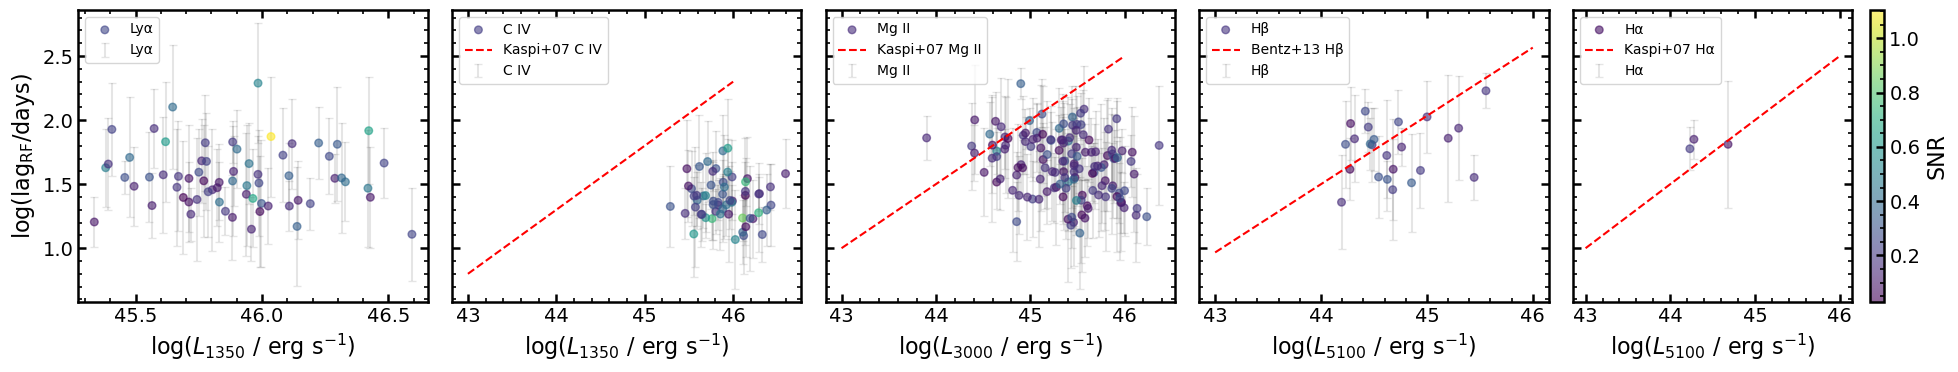

In [164]:
import matplotlib.pyplot as plt
import numpy as np

broad_lines = ["Lyα 1216", "C IV 1549", "Mg II 2798", "Hβ 4861", "Hα 6563"]
conti_lam =   [1350,       1350,        3000,          5100,      5100]

fig, axes = plt.subplots(1, len(broad_lines), figsize=(4 * len(broad_lines), 4), sharey=True)
lines_by_obj = [sdss_broad_lines_by_band(z) for z in df_agn['z']]

# Gather all SNR values for color normalization
all_snr = []
all_logl = []
all_lag = []
all_lag_err = []
all_z = []
all_panel = []

for i, line in enumerate(broad_lines):
    mask = np.array([line in d.values() for d in lines_by_obj])
    z = df_agn['z'][mask]
    logl = df_agn[f'LOGL{conti_lam[i]}'][mask]
    bands_for_line = [next(b for b, l in d.items() if l == line) for d in np.array(lines_by_obj)[mask]]
    lag = np.array([df_agn[f'log_lag_blr_{b}'][j] for j, b in zip(np.where(mask)[0], bands_for_line)])
    lag_err = np.array([df_agn[f'log_lag_blr_{b}_err'][j] for j, b in zip(np.where(mask)[0], bands_for_line)])
    log_sigma_band = np.array([df_agn[f'log_sigma_band_{b}'][j] for j, b in zip(np.where(mask)[0], bands_for_line)])
    log_sigma_blr = np.array([df_agn[f'log_sigma_band_{b}'][j] + df_agn[f'log_amp_delta_blr_{b}'][j] for j, b in zip(np.where(mask)[0], bands_for_line)])
    snr = 10**log_sigma_blr / 10**log_sigma_band
    mask2 = (lag_err < 0.5) & (logl > 0)
    # Store for global color scale
    all_snr.append(snr[mask2])
    all_logl.append(logl[mask2])
    all_lag.append(lag[mask2] - np.log10(1 + z[mask2]))
    all_lag_err.append(lag_err[mask2])
    all_z.append(z[mask2])
    all_panel.append(np.full(np.sum(mask2), i))

# Flatten arrays
all_snr = np.concatenate(all_snr)
all_logl = np.concatenate(all_logl)
all_lag = np.concatenate(all_lag)
all_lag_err = np.concatenate(all_lag_err)
all_z = np.concatenate(all_z)
all_panel = np.concatenate(all_panel)

# Get global vmin/vmax for color scale
vmin, vmax = np.nanmin(all_snr), np.nanmax(all_snr)

scs = []
for i, line in enumerate(broad_lines):
    idx = (all_panel == i)
    sc = axes[i].scatter(all_logl[idx], all_lag[idx], s=30, c=all_snr[idx], cmap='viridis', alpha=0.6, vmin=vmin, vmax=vmax, label=f'{line[:-5]}')
    scs.append(sc)
    axes[i].errorbar(all_logl[idx], all_lag[idx], yerr=all_lag_err[idx], linestyle='none', marker='none', alpha=0.1, label=line[:-5], color='k', zorder=-1)
    if broad_lines[i] == "Hα 6563":
        axes[i].plot([43, 46], [1.5 + 0.5 * (x - 44) for x in [43, 46]], 'r--', label='Kaspi+07 Hα')
    elif broad_lines[i] == "Hβ 4861":
        axes[i].plot([43, 46], [1.5 + 0.533 * (x - 44) for x in [43, 46]], 'r--', label='Bentz+13 Hβ')
    elif broad_lines[i] == "Mg II 2798":
        axes[i].plot([43, 46], [1.5 + 0.5 * (x - 44) for x in [43, 46]], 'r--', label='Kaspi+07 Mg II')
    elif broad_lines[i] == "C IV 1549":
        axes[i].plot([43, 46], [1.3 + 0.5 * (x - 44) for x in [43, 46]], 'r--', label='Kaspi+07 C IV')
    axes[i].legend(loc='upper left', fontsize=10)
    axes[i].set_xlabel(rf'$\log( L_{{{conti_lam[i]}}} \ /\ \mathrm{{erg}} \ \mathrm{{s}}^{{-1}} )$')
    if i == 0:
        axes[i].set_ylabel(r'$\log(\mathrm{lag}_{\mathrm{RF}} / \mathrm{days})$')
    # Only add colorbar to the rightmost panel
    if i == len(broad_lines) - 1:
        fig.colorbar(scs[i], ax=axes[i], label='SNR')

plt.tight_layout()
plt.show()